# Replacing a kernel with a trained model

`Macrophysics` is CAM's cloud macrophysics stage as a Python class.  Its
control flow is Python and every floating-point number is the pinned
iCESM Fortran's, reached through one method -- `mmacro_pcond` -- which is
the only place in the class that says what computes its numerical core.

That is what makes a replacement complete rather than partial.  The walk
over a chunk calls that method for every live column, and a notebook calls
it for a column of its own, so putting a trained network in its place
changes both callers at once: there is no second definition left holding
the original.

This notebook does that with a network trained on the model's own captured
columns, and then asks the only questions worth asking of it -- where it
is right, where it is not, and whether it responds to the namelist.

## Artefacts

Two files, both produced by `validation/jobs/pi_cam_mmacro_dataset_build.pbs`:
the anchors drawn out of a 50-step, 512-rank capture, and the network
trained on samples anchored on them.  Point `RUN` at your own job's output.

In [1]:
import os, sys
from pathlib import Path

REPO = Path.cwd()
while REPO != REPO.parent and not (REPO / 'pyproject.toml').is_file():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'src'))
from freecam import site

SCRATCH = site.resolved(repo=REPO)['scratch']

def newest(paths):
    ranked = sorted(paths, key=lambda path: path.stat().st_mtime, reverse=True)
    return ranked[0] if ranked else None


def largest(paths):
    # Anchor bundles differ by how many real columns they hold, and the
    # biggest is the one worth testing against.
    ranked = sorted(paths, key=lambda path: path.stat().st_size, reverse=True)
    return ranked[0] if ranked else None

# The trained surrogate the site points at, else the most recent one this
# user's own dataset jobs produced.
RUN = site.path('FREECAM_SURROGATE', repo=REPO)
if RUN is None:
    RUN = newest(run for run in SCRATCH.glob('pyCAM/PI-cam/mmacro-dataset-*')
                 if (run / 'mmacro_gated.pt').is_file())
assert RUN is not None, (
    'no trained surrogate.  Point FREECAM_SURROGATE in site.env at one, or\n'
    '  train one: validation/jobs/submit.sh'
    ' validation/jobs/pi_cam_mmacro_dataset_build.pbs')
MODEL = RUN / 'mmacro_gated.pt'

# Real columns to test on.  Anchors are a property of the dataset, not of a
# training run: a job that retrains on an existing set writes no new ones.
ANCHORS = RUN / 'anchors.npz'
if not ANCHORS.is_file():
    ANCHORS = largest([*SCRATCH.glob('pyCAM/PI-cam/*/anchors.npz'),
                       *SCRATCH.glob('pyCAM/kernel-training/anchors_*.npz')])
assert ANCHORS is not None and ANCHORS.is_file(), (
    'no anchor bundle.  examples/generate_training_data.ipynb writes one')

print(f'surrogate: {RUN.name}')
print(f'  model    {MODEL.name}  ({MODEL.stat().st_size / 1e6:.1f} MB)')
print(f'  anchors  {ANCHORS.relative_to(SCRATCH)}')


surrogate: mmacro-dataset-7263973.desched1
  model    mmacro_gated.pt  (18.2 MB)
  anchors  pyCAM/PI-cam/mmacro-dataset-7259093.desched1/anchors.npz


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import freecam as fc
from freecam.physics.macrophysics import Macrophysics
from freecam.physics.surrogate import load_surrogate

scheme = fc.physics.load_function('mmacro_pcond')
column = scheme.example_input('captured-anchor')
print(scheme.describe().splitlines()[0])

cldwat2m_macro::mmacro_pcond  (components/cam/src/physics/cam/cldwat2m_macro.F90)


## 1. The class computes its own core

No driver, no MPI: the class on its own, one column in and one column out.
`kernels['mmacro_pcond']` is empty, so the method calls the reviewed
standalone image -- the oracle's own object code, linked from the pinned
source.

In [3]:
oracle = Macrophysics()
answer = oracle.mmacro_pcond(column)

print('kernel slot empty  :', oracle.kernels['mmacro_pcond'] is None)
print('outputs            :', len(answer.outputs), 'arguments')
print('updated states     :', len(answer.updated_inputs), 'arguments')
print('cloud fraction sum :', float(np.sum(answer.outputs['cld'])))

kernel slot empty  : True
outputs            : 17 arguments
updated states     : 6 arguments
cloud fraction sum : 0.15907820744904863


## 2. Put a network in its place

Two ways in, one place they arrive.  Assigning into `kernels` is what a
notebook does; `Macrophysics(surrogate=...)` is what a 512-rank run does,
because a stage is pickled to every rank and a loaded network is not
picklable -- the path travels instead and each rank loads its own.

Binding the method directly with `MethodType` reaches the same code.

In [4]:
from types import MethodType

network = load_surrogate(MODEL)

by_slot = Macrophysics()
by_slot.kernels['mmacro_pcond'] = network

by_path = Macrophysics(surrogate=MODEL)          # what the model run uses

by_method = Macrophysics()
by_method.mmacro_pcond = MethodType(network.as_method(), by_method)

answers = [stage.mmacro_pcond(column) for stage in (by_slot, by_path, by_method)]
same = all(np.array_equal(answers[0].outputs['cld'], other.outputs['cld'])
           for other in answers[1:])
print('three ways in, one answer out:', same)
print('weights:', sum(p.numel() for p in network.net.parameters()) / 1e6, 'M')

three ways in, one answer out: True
weights: 4.484512 M


## 3. One column, both answers

The network answers every argument the routine answers, under the same
names, so it drops into the same slot.  Whether the answers are any good is
a separate question, and the profile is the first place to look.

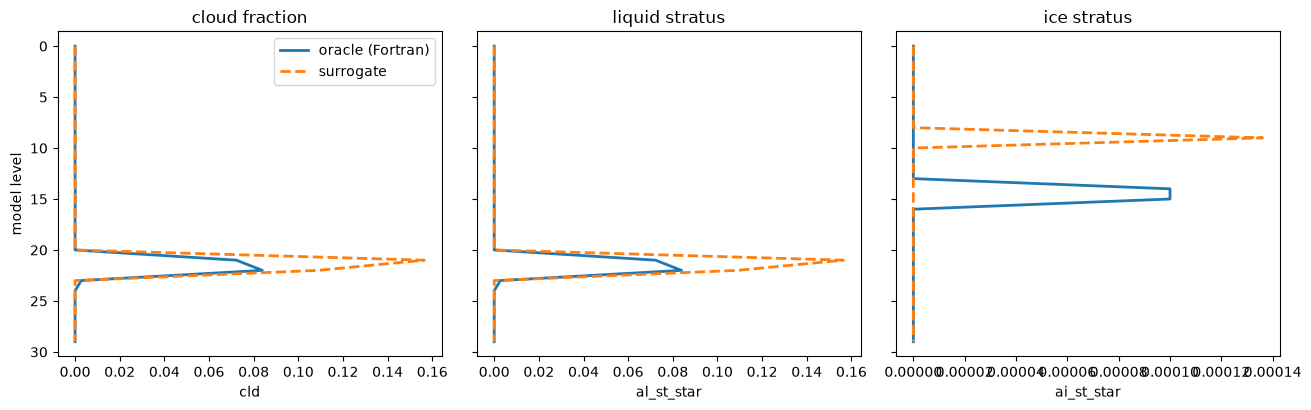

In [5]:
model = answers[0]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
level = np.arange(column['t0'].size)
for ax, name, label in zip(axes,
                           ('cld', 'al_st_star', 'ai_st_star'),
                           ('cloud fraction', 'liquid stratus', 'ice stratus')):
    ax.plot(answer.outputs[name], level, label='oracle (Fortran)', lw=2)
    ax.plot(model.outputs[name], level, label='surrogate', lw=2, ls='--')
    ax.set_title(label); ax.set_xlabel(name); ax.invert_yaxis()
axes[0].set_ylabel('model level'); axes[0].legend()
fig.tight_layout()

## 4. Where it is right, over many columns

One column says nothing about an intermittent field.  These draw real
columns out of the capture -- states the model actually visited -- and ask
three separate questions of each argument:

* does the term **fire** where the routine fires it;
* is the **sign** right where it does;
* how far off is the **magnitude**, in decades, so a factor of two (0.30)
  is told apart from four orders (4.0).

In [6]:
anchors = np.load(ANCHORS, allow_pickle=True)
names = [n for n in anchors.files if not n.startswith('meta_') and n != 'provenance']
rng = np.random.default_rng(0)

# Take the rows out of the archive once.  A member of an npz is
# decompressed whole on every index, so reading anchors[name][i] inside
# the loop unpacks a 48 MB array for each column and each argument -- ten
# thousand times over, which is enough to end the kernel rather than the
# cell.
picked = rng.choice(len(anchors['t0']), 200, replace=False)
columns = {name: np.asarray(anchors[name])[picked] for name in names}

truth, guess = [], []
for row in range(len(picked)):
    real = {name: values[row] for name, values in columns.items()}
    truth.append(oracle.mmacro_pcond(real))
    guess.append(by_slot.mmacro_pcond(real))
print(len(truth), 'real columns through both the Fortran and the network')

200 real columns through both the Fortran and the network


In [7]:
UPDATED = ('t0', 'qv0', 'ql0', 'qi0', 'nl0', 'ni0')
FLOOR = 1e-12          # below this the routine's answers are round-off

def stack(results, name, base=None):
    both = [r.updated_inputs if name in r.updated_inputs else r.outputs for r in results]
    values = np.array([np.asarray(b[name], dtype=float).reshape(-1) for b in both])
    return values - base if base is not None else values

print(f"{'argument':12s} {'fires':>7s} {'gate P':>7s} {'gate R':>7s} {'sign':>6s} {'decades':>8s}")
for name in (*UPDATED, 'cld', 'qme', 'qladj', 'al_st_star', 'ai_st_star'):
    base = np.asarray(columns[name], dtype=float) if name in UPDATED else None
    t, p = stack(truth, name, base), stack(guess, name, base)
    fires, said = np.abs(t) > FLOOR, np.abs(p) > FLOOR
    both = fires & said
    P = (both.sum() / max(said.sum(), 1))
    R = (both.sum() / max(fires.sum(), 1))
    sign = (np.sign(t[both]) == np.sign(p[both])).mean() if both.any() else np.nan
    dec = np.median(np.abs(np.log10(np.abs(p[both])) - np.log10(np.abs(t[both])))) \
        if both.any() else np.nan
    print(f'{name:12s} {fires.mean():7.3f} {P:7.2f} {R:7.2f} {sign:6.2f} {dec:8.2f}')

argument       fires  gate P  gate R   sign  decades
t0             0.976    1.00    1.00   0.99     0.00
qv0            0.972    1.00    1.00   0.98     0.00
ql0            0.189    0.71    0.98   0.77     0.38
qi0            0.276    0.98    1.00   1.00     0.00
nl0            0.202    0.69    0.97   0.75     0.13
ni0            0.279    0.87    0.98   0.98     0.00
cld            0.420    0.92    0.92   1.00     0.19
qme            0.254    0.90    0.96   0.92     0.23
qladj          0.002    0.02    0.89   1.00     0.30
al_st_star     0.173    0.85    0.94   1.00     0.21
ai_st_star     0.269    0.84    0.87   1.00     0.49


Read the table as three separate verdicts.  A high firing rate with a low
precision means the network invents the term where the routine leaves it
alone -- the direction that manufactures condensate out of nothing.  A
median of 0.3 decades is a factor of two on the typical case and says
nothing about the tail, which is where a kernel inside a model gets into
trouble.

## 5. Does it respond to the namelist?

This is the question a surrogate trained on a single model run cannot pass.
A capture holds one `atm_in`, so every sample in it carries the same nine
tunable parameters and a network fitted to it is a function of the state
alone: change `cldfrc_rhminl` and it answers exactly the same numbers, in
silence.

This network was fitted on samples whose parameters were drawn per sample,
with the nine among its features, so the namelist reaches it.

correlation across the sweep: 0.993


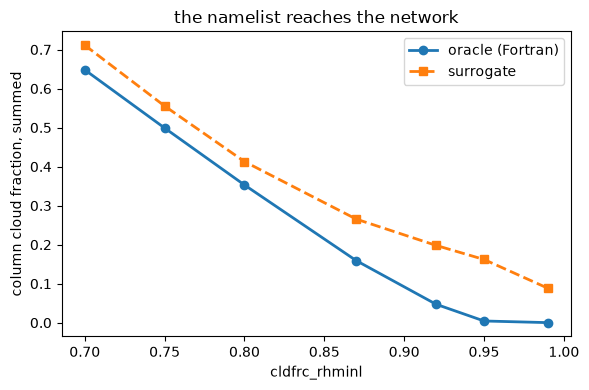

In [8]:
SWEEP = (0.70, 0.75, 0.80, 0.87, 0.92, 0.95, 0.99)

fortran, network_answer = [], []
for rhminl in SWEEP:
    knob = {'cldfrc_rhminl': rhminl}
    fortran.append(float(np.sum(oracle.mmacro_pcond(column, knob).outputs['cld'])))
    network_answer.append(float(np.sum(by_slot.mmacro_pcond(column, knob).outputs['cld'])))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(SWEEP, fortran, 'o-', lw=2, label='oracle (Fortran)')
ax.plot(SWEEP, network_answer, 's--', lw=2, label='surrogate')
ax.set_xlabel('cldfrc_rhminl'); ax.set_ylabel('column cloud fraction, summed')
ax.set_title('the namelist reaches the network')
ax.legend(); fig.tight_layout()
print('correlation across the sweep:', np.corrcoef(fortran, network_answer)[0, 1].round(3))

## 6. The same swap, at 512 ranks

Nothing above changes when the stage runs inside the model.  The walk calls
the same method for every live column of every chunk, so the run is driven
by one flag:

```
freecam ... --macrophysics-python --macro-kernel-surrogate <model>.pt
```

`validation/jobs/pi_cam_macro_surrogate_50step.pbs` runs it.  Two things
about that run are worth saying plainly.

It is **not** bit-for-bit and cannot be: a network is different arithmetic,
and the replay's export check stops it at the first step.  For a surrogate
the gate's job changes from pass/fail to measurement, which is why the job
passes `--no-verify-exports` and reads the stage trace instead.

And a surrogate's own errors push the model off the manifold its training
came from, so the run is the only place the tail shows up.  What stopped
the run recorded here was not the condensate -- CAM's bounds checks fired
twenty times less often than for the previous network, and the worst
violation was 1e-9 rather than 1e+3 kg/kg -- but water-isotope mass
conservation, which nothing in the loss function asks the network to
respect.

In [9]:
scheme.close()